In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.5.0+cu124'

In [3]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing 
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

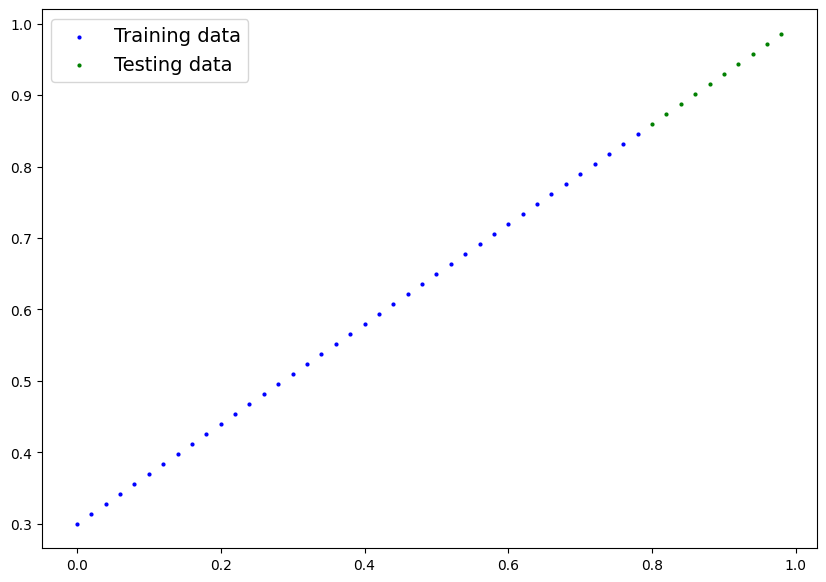

In [6]:
plot_predictions();

In [35]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [36]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [37]:
# List named parameters 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [38]:
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [39]:
loss_fn = nn.L1Loss() # <- also known as mean absolute error (MAE)


optimizer = torch.optim.SGD(model_0.parameters(), # <- model parameters to optimize
                            lr = 0.01)

In [40]:
torch.manual_seed(42)
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []


for epoch in range(epochs):
    model_0.train() # <- set the model to training mode

    y_preds = model_0(X_train) # <- forward pass (this is where the model makes predictions on the training data)

    loss = loss_fn(y_preds, y_train) # <- calculate the loss (how far off are our predictions from the truth?)

    optimizer.zero_grad() # <- zero the gradients (PyTorch accumulates gradients by default)

    loss.backward() # <- backward pass (this is where the magic happens and PyTorch calculates the gradients)

    optimizer.step() # <- step the optimizer (this is where the optimizer updates the parameters with the gradients)

    model_0.eval() # <- set the model to evaluation mode
    with torch.inference_mode():
        test_preds = model_0(X_test) # <- make predictions on the test data
        test_loss = loss_fn(test_preds, y_test) # <- calculate the test loss

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")
        model_0.state_dict()

Epoch: 0 | Loss: 0.3129 | Test Loss: 0.4811
Epoch: 10 | Loss: 0.1977 | Test Loss: 0.3464
Epoch: 20 | Loss: 0.0891 | Test Loss: 0.2173
Epoch: 30 | Loss: 0.0531 | Test Loss: 0.1446
Epoch: 40 | Loss: 0.0454 | Test Loss: 0.1136
Epoch: 50 | Loss: 0.0417 | Test Loss: 0.0992
Epoch: 60 | Loss: 0.0382 | Test Loss: 0.0889
Epoch: 70 | Loss: 0.0348 | Test Loss: 0.0806
Epoch: 80 | Loss: 0.0313 | Test Loss: 0.0723
Epoch: 90 | Loss: 0.0279 | Test Loss: 0.0647
Epoch: 100 | Loss: 0.0245 | Test Loss: 0.0565
Epoch: 110 | Loss: 0.0210 | Test Loss: 0.0482
Epoch: 120 | Loss: 0.0176 | Test Loss: 0.0406
Epoch: 130 | Loss: 0.0142 | Test Loss: 0.0323
Epoch: 140 | Loss: 0.0107 | Test Loss: 0.0241
Epoch: 150 | Loss: 0.0073 | Test Loss: 0.0165
Epoch: 160 | Loss: 0.0039 | Test Loss: 0.0082
Epoch: 170 | Loss: 0.0089 | Test Loss: 0.0050
Epoch: 180 | Loss: 0.0089 | Test Loss: 0.0050
Epoch: 190 | Loss: 0.0089 | Test Loss: 0.0050


In [27]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [14]:
weight, bias

(0.7, 0.3)

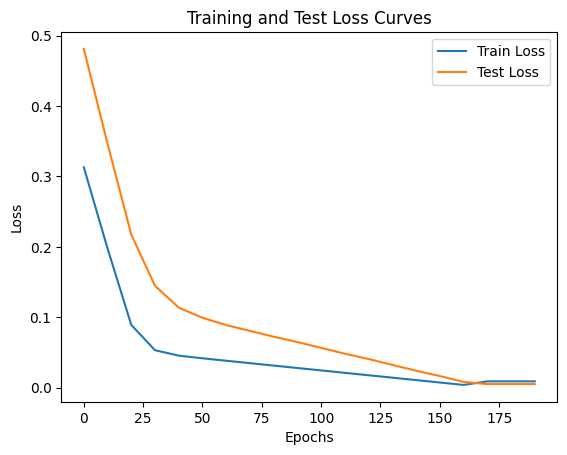

In [41]:
plt.plot(epoch_count,loss_values, label="Train Loss")
plt.plot(epoch_count,test_loss_values, label="Test Loss")
plt.title("Training and Test Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

In [43]:
with torch.inference_mode():
    y_preds = model_0(X_test)

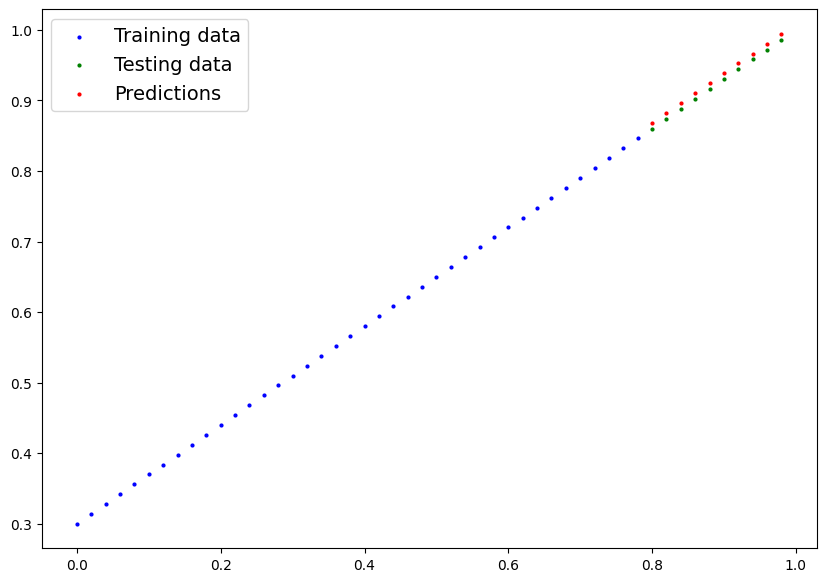

In [44]:
plot_predictions(predictions=y_preds)

In [45]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [46]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

/tmp/ipykernel_11282/769840282.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))


<All keys matched successfully>

In [47]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [48]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])